# Malaysia's E-Waste Opportunity: Sizing the Recoverable Value

## The Question

How much economic value (in recoverable copper, gold, and silver) sits inside Malaysia's e-waste stream, at current metal prices? Before asking whether formal e-waste recycling is a viable business (Notebook 02), the more basic question is whether there's enough value there to matter at all.

## The Answer

An estimated **USD 260 million to 520 million** in recoverable copper, gold, and silver, based on Malaysia's estimated 2019 e-waste generation (364,000 tonnes), published research on the metal content of printed circuit boards, and current (August 2026) metal prices. Gold drives roughly **90% of that value**, despite printed circuit boards being a small fraction of e-waste's total weight and gold an even smaller fraction of that. This is a wide range, not a precise figure; it reflects real uncertainty in the underlying assumptions (see Confidence & Caveats), not false precision. The range itself is the honest answer: this is a large number under any reasonable assumption, which is the point of this notebook; whether formal recycling can actually *capture* that value is a separate question, addressed in Notebook 02.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

generation = pd.read_csv('../data/processed/ewaste_generation_estimate.csv')
metal_content = pd.read_csv('../data/processed/pcb_metal_content.csv')
pcb_share = pd.read_csv('../data/processed/pcb_share_of_ewaste.csv')
prices = pd.read_csv('../data/processed/metal_prices.csv')
generation

,year,tonnes_generated,scope,source,classification
0,2019,364000,"All e-waste categories (UNU-KEYS, all product ...","UN Global E-waste Monitor 2020, as cited in Mo...",ESTIMATED


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Building the estimate: generation → PCB mass → metal mass → value

Each step below is a real, cited assumption, not a single "true" number. `DATA_DICTIONARY.md` documents exactly how well-sourced each one is; they are not all equally strong.

In [3]:
generation_tonnes = generation['tonnes_generated'].iloc[0]

# Step 1: how much of the e-waste stream is printed circuit boards?
pcb_share_low = pcb_share.loc[pcb_share['estimate_type'] == 'Low', 'share_pct'].iloc[0] / 100
pcb_share_high = pcb_share.loc[pcb_share['estimate_type'] == 'High', 'share_pct'].iloc[0] / 100

# Step 2: metal content per tonne of PCB (Bizzo et al. 2014)
cu_kg_per_tonne_pcb = metal_content.loc[metal_content['metal'] == 'Copper', 'content_value'].iloc[0] * 10  # wt% -> kg/tonne
au_g_per_tonne_pcb = metal_content.loc[metal_content['metal'] == 'Gold', 'content_value'].iloc[0]  # already ppm = g/tonne
ag_g_per_tonne_pcb = metal_content.loc[metal_content['metal'] == 'Silver', 'content_value'].iloc[0]

# Step 3: current spot prices
price_au = prices.loc[prices['metal'] == 'Gold', 'price_usd_per_gram'].iloc[0]
price_ag = prices.loc[prices['metal'] == 'Silver', 'price_usd_per_gram'].iloc[0]
price_cu = prices.loc[prices['metal'] == 'Copper', 'price_usd_per_gram'].iloc[0]

rows = []
for label, share in [('Low (3% PCB share)', pcb_share_low), ('High (6% PCB share)', pcb_share_high)]:
    pcb_tonnes = generation_tonnes * share
    cu_value = pcb_tonnes * cu_kg_per_tonne_pcb * 1000 * price_cu
    au_value = pcb_tonnes * au_g_per_tonne_pcb * price_au
    ag_value = pcb_tonnes * ag_g_per_tonne_pcb * price_ag
    rows.append({'scenario': label, 'pcb_tonnes': round(pcb_tonnes),
                 'copper_usd': round(cu_value), 'gold_usd': round(au_value),
                 'silver_usd': round(ag_value), 'total_usd': round(cu_value + au_value + ag_value)})

value_df = pd.DataFrame(rows).set_index('scenario')
value_df

,pcb_tonnes,copper_usd,gold_usd,silver_usd,total_usd
scenario,,,,,
Low (3% PCB share),10920,22360229,229401682,7823306,259585217
High (6% PCB share),21840,44720458,458803363,15646613,519170434


## Visualizing where the value actually comes from

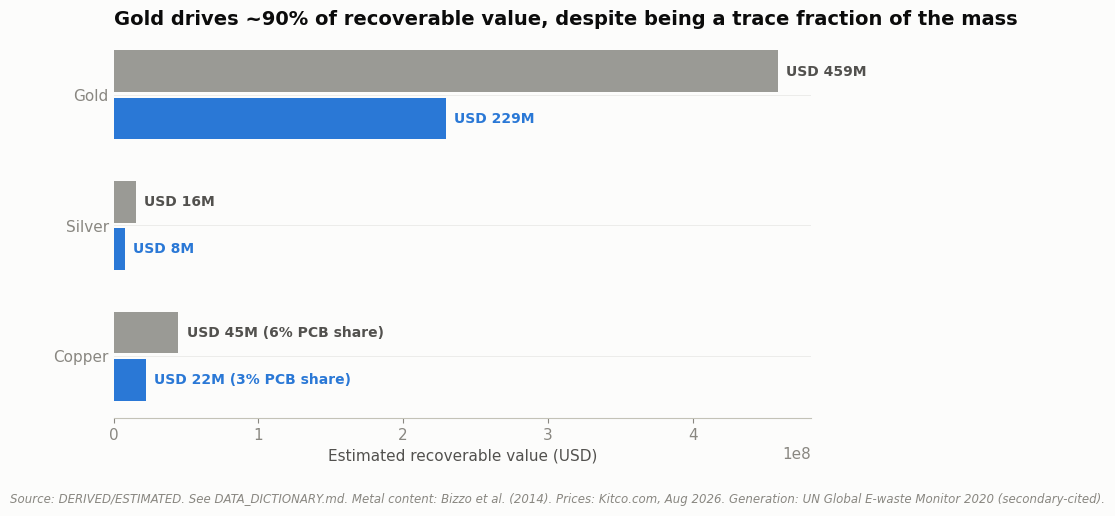

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
metals = ['Copper', 'Silver', 'Gold']
low_vals = [value_df.loc['Low (3% PCB share)', 'copper_usd'],
            value_df.loc['Low (3% PCB share)', 'silver_usd'],
            value_df.loc['Low (3% PCB share)', 'gold_usd']]
high_vals = [value_df.loc['High (6% PCB share)', 'copper_usd'],
             value_df.loc['High (6% PCB share)', 'silver_usd'],
             value_df.loc['High (6% PCB share)', 'gold_usd']]

y = range(len(metals))
ax.barh([i + 0.18 for i in y], high_vals, height=0.32, color=GRAY)
ax.barh([i - 0.18 for i in y], low_vals, height=0.32, color=ACCENT_1)

for i, (lo, hi) in enumerate(zip(low_vals, high_vals)):
    lo_label = f'USD {lo/1e6:,.0f}M (3% PCB share)' if i == 0 else f'USD {lo/1e6:,.0f}M'
    hi_label = f'USD {hi/1e6:,.0f}M (6% PCB share)' if i == 0 else f'USD {hi/1e6:,.0f}M'
    ax.annotate(lo_label, xy=(lo, i - 0.18), xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=10, fontweight='semibold', color=ACCENT_1)
    ax.annotate(hi_label, xy=(hi, i + 0.18), xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=10, fontweight='semibold', color=INK_SECONDARY)

ax.set_yticks(list(y))
ax.set_yticklabels(metals)
ax.set_title('Gold drives ~90% of recoverable value, despite being a trace fraction of the mass', loc='left')
ax.set_xlabel('Estimated recoverable value (USD)')
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

add_source(ax.figure, 'Source: DERIVED/ESTIMATED. See DATA_DICTIONARY.md. Metal content: Bizzo et al. (2014). '
                       'Prices: Kitco.com, Aug 2026. Generation: UN Global E-waste Monitor 2020 (secondary-cited).')
plt.show()


## Strategic Recommendation

- **The opportunity is large enough to be worth investigating further, under any reasonable assumption in this range.** Even the low end of this estimate (~USD 260 million) is a meaningful number for a business evaluating whether to enter formal e-waste metal recovery in Malaysia.
- **Gold is the number that matters, not copper, and not overall tonnage.** A business modeling this opportunity should focus its sourcing and processing strategy on maximizing gold recovery specifically; copper and silver are worth capturing but are not what makes this economically interesting.
- **This notebook sizes the opportunity, not the business case.** A large recoverable-value estimate does not by itself mean formal recycling is profitable or that this value is actually capturable; collection logistics, processing costs, and competition from the informal sector are the real gating questions, addressed in Notebook 02.

## Confidence & Caveats

- **This is the most ESTIMATED-heavy analysis in this portfolio to date.** Every input in this chain (generation tonnage, PCB share of e-waste mass, and metal content per tonne) carries real uncertainty, documented input-by-input in `DATA_DICTIONARY.md`. The USD 260M–520M range should be read as "large, by an order of magnitude", not as a number precise to the dollar.
- **The generation figure (364,000 tonnes, 2019) was not independently verified against a primary UN document.** The original Global E-waste Monitor report was inaccessible this session (gated registration form, or an unparseable PDF); the figure is sourced via a secondary academic citation only.
- **The metal-content assumption (Bizzo et al. 2014) sampled old desktop computer PCBs (XT/486/Pentium-era)**, not current laptops, phones, or other device categories, and the same paper documents that PCB gold content has declined over decades. Today's actual average is very likely different, in an unknown direction, from this one study's figure.
- **Palladium is excluded entirely**, understating total value, because the source study didn't detect it and mixing in a figure from a different, less-consistent source would have been worse than leaving it out.
- **No processing or collection costs are included.** This is a *gross* recoverable-value estimate, not a profit estimate. See Notebook 02 for why that distinction matters a great deal here.